In [9]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2                          # ← BARU
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input       # ← BARU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print('=' * 55)
print('✅ Semua library berhasil diimport!')
print(f'   TensorFlow versi : {tf.__version__}')
gpu = tf.config.list_physical_devices('GPU')
if gpu:
    print(f'   GPU              : ✅ Aktif ({gpu[0].name})')
else:
    print(f'   GPU              : ❌ Tidak aktif (aktifkan T4 GPU!)')
print('=' * 55)

✅ Semua library berhasil diimport!
   TensorFlow versi : 2.20.0
   GPU              : ✅ Aktif (/physical_device:GPU:0)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH  = '/content/drive/MyDrive/dataset_gambar'   # ← sesuaikan jika beda
MODEL_SAVE_DIR = '/content/drive/MyDrive/model_pisang'
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, 'cnn_kematangan_pisang.keras')
CONFIG_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, 'config.json')

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Konfigurasi MobileNetV2
IMG_SIZE      = (224, 224)   # ← ubah dari 128 ke 224
BATCH_SIZE    = 32           # ← naikkan dari 16
EPOCHS_HEAD   = 15           # Phase 1: train head saja
EPOCHS_FINE   = 20           # Phase 2: fine-tuning
LR_HEAD       = 1e-3         # Learning rate phase 1
LR_FINE       = 1e-5         # Learning rate phase 2 (harus kecil!)
SEED          = 42

# ── Label tampilan ────────────────────────────────────────────────────────────
LABEL_DISPLAY = {
    'banana unripe'    : '🟢 Unripe (Mentah)',
    'banana semi-ripe' : '🟡 Semi-Ripe (Setengah Matang)',
    'banana fully-ripe': '🟠 Fully-Ripe (Matang)'
}
WARNA_KELAS = ['#22c55e', '#eab308', '#f97316']  # hijau, kuning, oranye

# ── Verifikasi path ───────────────────────────────────────────────────────────
print()
if os.path.exists(DATASET_PATH):
    subfolder = sorted([d for d in os.listdir(DATASET_PATH)
                        if os.path.isdir(os.path.join(DATASET_PATH, d))])
    print(f'✅ Dataset ditemukan!')
    print(f'   Path      : {DATASET_PATH}')
    print(f'   Subfolder : {subfolder}')
else:
    print(f'❌ Path TIDAK ditemukan: {DATASET_PATH}')
    print('   Periksa kembali nama folder di Google Drive Anda.')

Mounted at /content/drive

✅ Dataset ditemukan!
   Path      : /content/drive/MyDrive/dataset_gambar
   Subfolder : ['banana fully-ripe', 'banana semi-ripe', 'banana unripe']


📁 Isi Dataset Pisang:
--------------------------------------------------
   🟢 Unripe (Mentah)                        : 150 gambar
   🟡 Semi-Ripe (Setengah Matang)            : 150 gambar
   🟠 Fully-Ripe (Matang)                    : 148 gambar
--------------------------------------------------
   Total                                    : 448 gambar


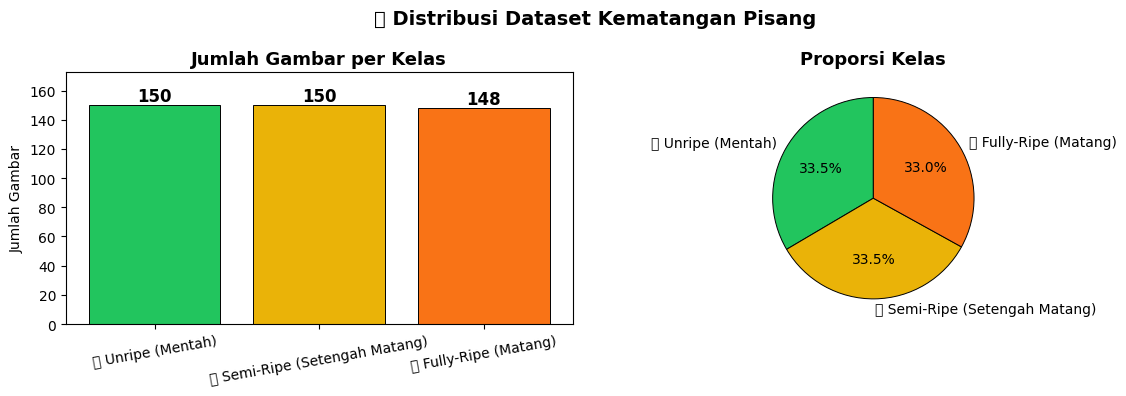

💾 Grafik disimpan: /content/distribusi_dataset.png


In [3]:
KELAS = ['banana unripe', 'banana semi-ripe', 'banana fully-ripe']

# ── Hitung gambar per kelas ───────────────────────────────────────────────────
print('📁 Isi Dataset Pisang:')
print('-' * 50)
counts = {}
for cls in KELAS:
    path_cls = os.path.join(DATASET_PATH, cls)
    if os.path.exists(path_cls):
        files = [f for f in os.listdir(path_cls)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        counts[cls] = len(files)
    else:
        counts[cls] = 0
    label = LABEL_DISPLAY.get(cls, cls)
    print(f'   {label:40s} : {counts[cls]} gambar')
print('-' * 50)
print(f'   Total{" ":35s} : {sum(counts.values())} gambar')

# ── Grafik distribusi ─────────────────────────────────────────────────────────
label_list = [LABEL_DISPLAY[c] for c in KELAS]
count_list = [counts[c] for c in KELAS]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(label_list, count_list, color=WARNA_KELAS,
                   edgecolor='black', linewidth=0.7)
for bar, n in zip(bars, count_list):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 str(n), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Jumlah Gambar per Kelas', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=10)
axes[0].set_ylim(0, max(count_list) * 1.15)

axes[1].pie(count_list, labels=label_list, colors=WARNA_KELAS,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.7})
axes[1].set_title('Proporsi Kelas', fontweight='bold', fontsize=13)

plt.suptitle('📊 Distribusi Dataset Kematangan Pisang',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/distribusi_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Grafik disimpan: /content/distribusi_dataset.png')

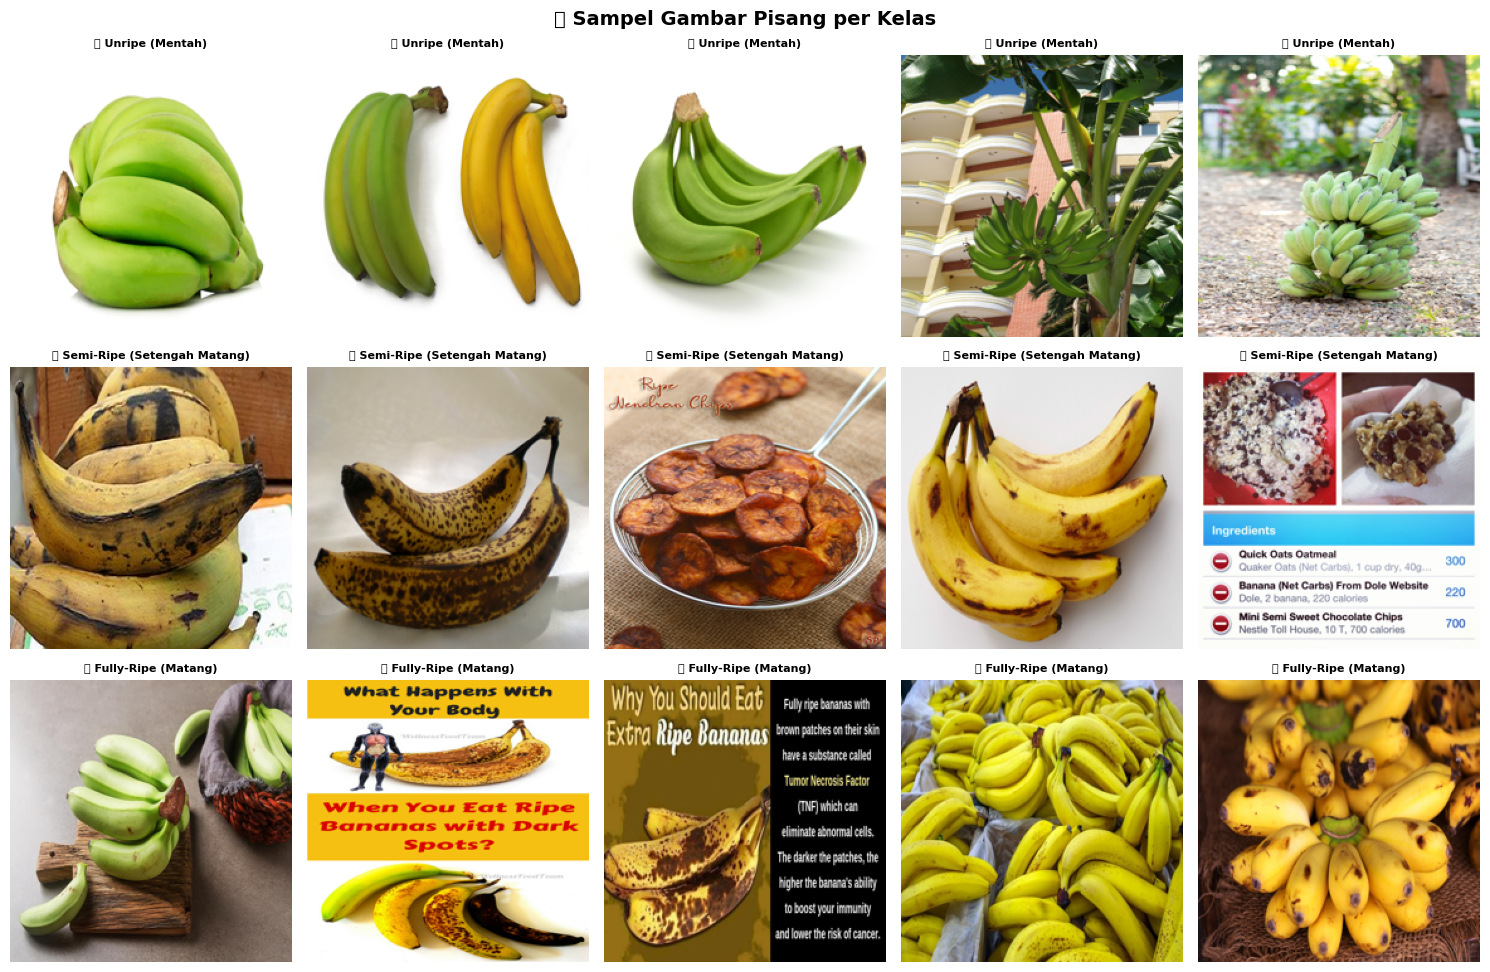

💾 Sampel gambar disimpan: /content/sampel_gambar.png


In [4]:
SAMPEL = 5
fig, axes = plt.subplots(3, SAMPEL, figsize=(SAMPEL * 3, 10))

for row, cls in enumerate(KELAS):
    path_cls = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(path_cls)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
    dipilih = np.random.choice(files, min(SAMPEL, len(files)), replace=False)

    for col, fname in enumerate(dipilih):
        img = Image.open(os.path.join(path_cls, fname)).resize(IMG_SIZE)
        axes[row][col].imshow(img)
        axes[row][col].set_title(LABEL_DISPLAY[cls], fontsize=8, fontweight='bold')
        axes[row][col].axis('off')
    for col in range(len(dipilih), SAMPEL):
        axes[row][col].axis('off')

plt.suptitle('🍌 Sampel Gambar Pisang per Kelas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sampel_gambar.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sampel gambar disimpan: /content/sampel_gambar.png')

In [5]:
# Data Generator dengan preprocess_input MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ← WAJIB, ganti rescale
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.15,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ← WAJIB, ganti rescale
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f'\n✅ Data berhasil dimuat!')
print(f'   Urutan kelas  : {train_data.class_indices}')
print(f'   Training      : {train_data.samples} gambar')
print(f'   Validasi      : {val_data.samples} gambar')
print(f'   IMG_SIZE      : {IMG_SIZE}')

Found 359 images belonging to 3 classes.
Found 89 images belonging to 3 classes.

✅ Data berhasil dimuat!
   Urutan kelas  : {'banana fully-ripe': 0, 'banana semi-ripe': 1, 'banana unripe': 2}
   Training      : 359 gambar
   Validasi      : 89 gambar
   IMG_SIZE      : (224, 224)


In [6]:
# Base MobileNetV2 — bobot dari ImageNet, tanpa top layer
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze semua layer (Phase 1)

# Tambah classifier custom untuk pisang
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\n✅ Model MobileNetV2 berhasil dibangun!')
print(f'   Total parameter   : {model.count_params():,}')
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'   Trainable sekarang: {trainable:,}  (hanya head, base frozen)')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


✅ Model MobileNetV2 berhasil dibangun!
   Total parameter   : 2,624,323
   Trainable sekarang: 363,779  (hanya head, base frozen)


In [7]:
# ── Phase 1: Latih hanya Classifier Head ─────────────────────
cb_early = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

print('🚀 Phase 1: Melatih Classifier Head (Base Frozen)...')
print('=' * 60)
history_head = model.fit(
    train_data,
    epochs=EPOCHS_HEAD,
    validation_data=val_data,
    callbacks=[cb_early, cb_lr],
    verbose=1
)

# ── Phase 2: Fine-Tuning (Unfreeze 50 layer terakhir) ────────
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_checkpoint = callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print('\n🚀 Phase 2: Fine-Tuning MobileNetV2...')
print('=' * 60)
history_fine = model.fit(
    train_data,
    epochs=EPOCHS_FINE,
    validation_data=val_data,
    callbacks=[cb_early, cb_lr, cb_checkpoint],
    verbose=1
)

print(f'\n✅ Training selesai!')
print(f'   Val accuracy terbaik: {max(history_fine.history["val_accuracy"]):.4f} '
      f'({max(history_fine.history["val_accuracy"])*100:.2f}%)')

🚀 Phase 1: Melatih Classifier Head (Base Frozen)...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.4791 - loss: 1.3216 - val_accuracy: 0.5056 - val_loss: 1.3382 - learning_rate: 0.0010
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6045 - loss: 1.0365 - val_accuracy: 0.5730 - val_loss: 1.0708 - learning_rate: 0.0010
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6880 - loss: 0.8619 - val_accuracy: 0.5281 - val_loss: 1.0937 - learning_rate: 0.0010
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7214 - loss: 0.7465 - val_accuracy: 0.5169 - val_loss: 1.1288 - learning_rate: 0.0010
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.7049 - loss: 0.7870
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 949ms/step - accuracy: 0.6936 - loss: 0.7244 - val_accuracy: 0.5056 - val_loss: 1.0775 - learning_rate: 0.0010
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 95

In [10]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
ep_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grafik Akurasi ────────────────────────────────────────────────────────────
axes[0].plot(ep_range, acc,     'b-o', label='Train',    markersize=4, linewidth=1.5)
axes[0].plot(ep_range, val_acc, 'r-s', label='Validasi', markersize=4, linewidth=1.5)
axes[0].axhline(y=max(val_acc), color='red', linestyle='--', alpha=0.5,
                label=f'Best val: {max(val_acc):.3f}')
axes[0].set_title('Akurasi Model CNN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# ── Grafik Loss ───────────────────────────────────────────────────────────────
axes[1].plot(ep_range, loss,     'b-o', label='Train',    markersize=4, linewidth=1.5)
axes[1].plot(ep_range, val_loss, 'r-s', label='Validasi', markersize=4, linewidth=1.5)
axes[1].set_title('Loss Model CNN', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('📈 Kurva Training CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/kurva_training.png', dpi=150, bbox_inches='tight')
plt.show()

best_ep = val_acc.index(max(val_acc)) + 1
print(f'\n🏆 Hasil Terbaik:')
print(f'   Val accuracy terbaik : {max(val_acc):.4f} ({max(val_acc)*100:.2f}%)')
print(f'   Dicapai pada epoch   : {best_ep}')
print(f'   Train accuracy akhir : {acc[-1]:.4f} ({acc[-1]*100:.2f}%)')
print('\n💡 Cara baca grafik:')
print('   ✅ Train & val naik bersama    → model belajar dengan baik')
print('   ⚠️  Train tinggi, val rendah   → overfitting (model hafal, tidak generalisasi)')
print('   ⚠️  Keduanya stagnan dari awal → underfitting (model tidak belajar)')

NameError: name 'history' is not defined

🔍 Memprediksi data validasi...
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

📊 Hasil Evaluasi:
   Accuracy : 0.5506 (55.06%)
   Loss     : 0.9765

CLASSIFICATION REPORT
                               precision    recall  f1-score   support

        🟠 Fully-Ripe (Matang)       0.48      0.38      0.42        29
🟡 Semi-Ripe (Setengah Matang)       0.47      0.60      0.53        30
            🟢 Unripe (Mentah)       0.71      0.67      0.69        30

                     accuracy                           0.55        89
                    macro avg       0.56      0.55      0.55        89
                 weighted avg       0.56      0.55      0.55        89



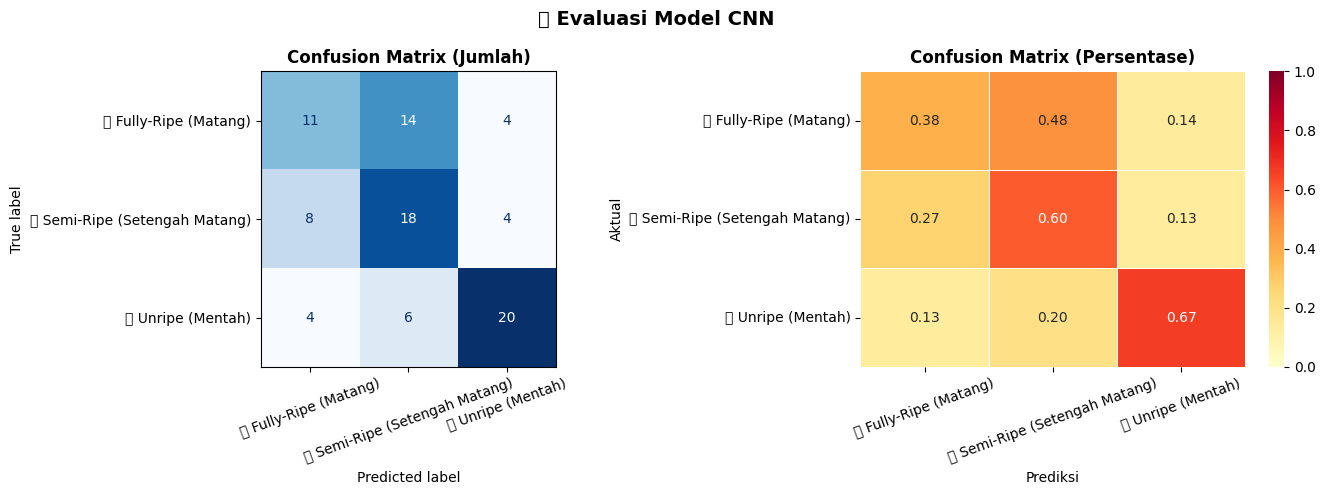


💡 Cara baca Confusion Matrix:
   Diagonal (kiri atas → kanan bawah) = prediksi BENAR
   Di luar diagonal = prediksi SALAH (perlu diperhatikan)


In [ ]:
# ── Prediksi semua data validasi ──────────────────────────────────────────────
val_data.reset()
print('🔍 Memprediksi data validasi...')
y_pred_prob = model.predict(val_data, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = val_data.classes

# ── Evaluasi total ────────────────────────────────────────────────────────────
val_data.reset()
val_loss_score, val_acc_score = model.evaluate(val_data, verbose=0)
print(f'\n📊 Hasil Evaluasi:')
print(f'   Accuracy : {val_acc_score:.4f} ({val_acc_score*100:.2f}%)')
print(f'   Loss     : {val_loss_score:.4f}')

# ── Classification Report ─────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
label_display_list = [LABEL_DISPLAY.get(c, c) for c in CLASS_NAMES]
print(classification_report(y_true, y_pred, target_names=label_display_list))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix jumlah
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_display_list)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Jumlah)', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)

# Confusion Matrix normalized (persentase)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=label_display_list,
            yticklabels=label_display_list,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Persentase)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Aktual')
axes[1].set_xlabel('Prediksi')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('📊 Evaluasi Model CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Cara baca Confusion Matrix:')
print('   Diagonal (kiri atas → kanan bawah) = prediksi BENAR')
print('   Di luar diagonal = prediksi SALAH (perlu diperhatikan)')

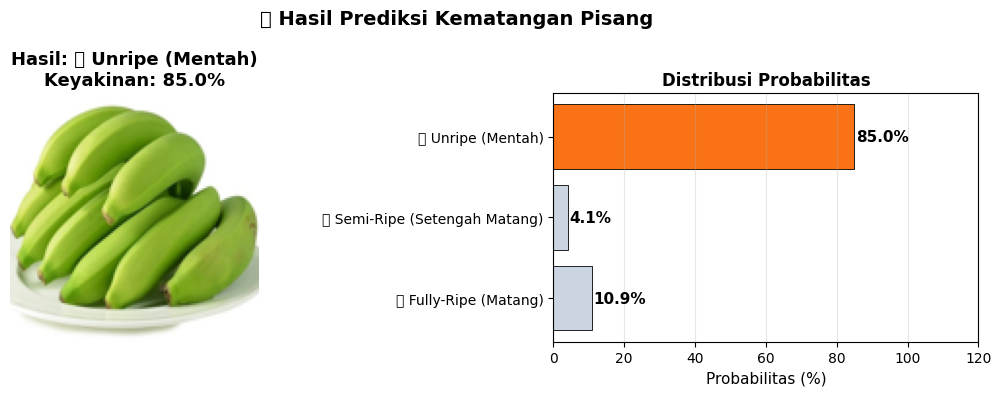


🍌 HASIL PREDIKSI KEMATANGAN PISANG
   🟠 Fully-Ripe (Matang)                   : 10.93%
   🟡 Semi-Ripe (Setengah Matang)           : 4.11%
   🟢 Unripe (Mentah)                       : 84.96% ✅ ← PREDIKSI

   Pisang ini tergolong: 🟢 Unripe (Mentah)
   Tingkat keyakinan   : 84.96%


('banana unripe', np.float32(84.95855))

In [ ]:
def prediksi_kematangan_pisang(path_gambar):
    """
    Prediksi tingkat kematangan pisang dari satu gambar.

    Parameter:
        path_gambar : str — path ke file gambar pisang

    Output:
        Menampilkan gambar + hasil prediksi + distribusi probabilitas
    """
    # ── 1. Load & preprocessing gambar ───────────────────────────────────────
    img     = Image.open(path_gambar).convert('RGB').resize(IMG_SIZE)
    arr     = np.array(img) / 255.0           # normalisasi
    arr     = np.expand_dims(arr, axis=0)     # bentuk: (1, 128, 128, 3)

    # ── 2. Prediksi ───────────────────────────────────────────────────────────
    probs     = model.predict(arr, verbose=0)[0]  # array probabilitas
    idx       = np.argmax(probs)                  # indeks kelas tertinggi
    kelas     = CLASS_NAMES[idx]                  # nama kelas
    keyakinan = probs[idx] * 100                  # persentase keyakinan
    label     = LABEL_DISPLAY.get(kelas, kelas)   # label cantik

    # ── 3. Tampilkan hasil ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Gambar pisang
    axes[0].imshow(img)
    axes[0].set_title(
        f'Hasil: {label}\nKeyakinan: {keyakinan:.1f}%',
        fontsize=13, fontweight='bold'
    )
    axes[0].axis('off')

    # Bar chart probabilitas
    label_list = [LABEL_DISPLAY.get(c, c) for c in CLASS_NAMES]
    warna_bar  = [WARNA_KELAS[i] if i == idx else '#cbd5e1'
                  for i in range(NUM_CLASSES)]
    bars = axes[1].barh(label_list, probs * 100,
                        color=warna_bar, edgecolor='black', linewidth=0.6)
    for bar, p in zip(bars, probs):
        axes[1].text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{p*100:.1f}%', va='center', fontsize=11, fontweight='bold'
        )
    axes[1].set_xlabel('Probabilitas (%)', fontsize=11)
    axes[1].set_title('Distribusi Probabilitas', fontsize=12, fontweight='bold')
    axes[1].set_xlim([0, 120])
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.suptitle('🍌 Hasil Prediksi Kematangan Pisang',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── 4. Cetak ringkasan teks ───────────────────────────────────────────────
    print('\n' + '=' * 50)
    print('🍌 HASIL PREDIKSI KEMATANGAN PISANG')
    print('=' * 50)
    for i, (c, p) in enumerate(zip(CLASS_NAMES, probs)):
        tanda = ' ✅ ← PREDIKSI' if i == idx else ''
        print(f'   {LABEL_DISPLAY.get(c, c):40s}: {p*100:.2f}%{tanda}')
    print('=' * 50)
    print(f'\n   Pisang ini tergolong: {label}')
    print(f'   Tingkat keyakinan   : {keyakinan:.2f}%')
    print('=' * 50)

    return kelas, keyakinan


# ── Demo: prediksi gambar acak dari dataset ───────────────────────────────────
kelas_demo = KELAS[0]
dir_demo   = os.path.join(DATASET_PATH, kelas_demo)
file_demo  = [f for f in os.listdir(dir_demo)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
path_demo  = os.path.join(dir_demo, file_demo)

prediksi_kematangan_pisang(path_demo)

📤 Pilih gambar pisang dari komputer Anda...


Saving Screenshot 2026-05-31 013141.png to Screenshot 2026-05-31 013141.png

🖼️  Memprediksi: Screenshot 2026-05-31 013141.png


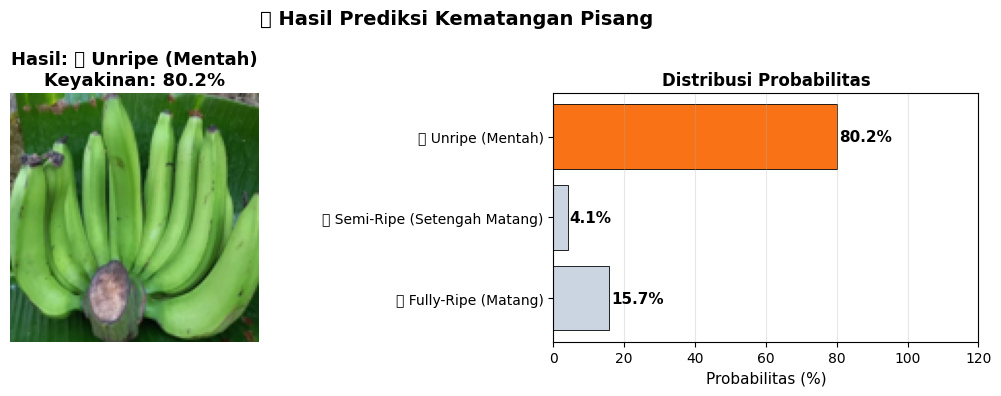


🍌 HASIL PREDIKSI KEMATANGAN PISANG
   🟠 Fully-Ripe (Matang)                   : 15.75%
   🟡 Semi-Ripe (Setengah Matang)           : 4.05%
   🟢 Unripe (Mentah)                       : 80.20% ✅ ← PREDIKSI

   Pisang ini tergolong: 🟢 Unripe (Mentah)
   Tingkat keyakinan   : 80.20%


In [ ]:
# ── Prediksi gambar pisang milik Anda sendiri ─────────────────────────────────
#
# Cara 1: Upload gambar langsung ke Colab
from google.colab import files
print('📤 Pilih gambar pisang dari komputer Anda...')
uploaded = files.upload()

for nama_file in uploaded.keys():
    path_upload = f'/content/{nama_file}'
    print(f'\n🖼️  Memprediksi: {nama_file}')
    prediksi_kematangan_pisang(path_upload)

In [ ]:
# ── Buat folder penyimpanan di Drive ─────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/model_pisang'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Simpan model ──────────────────────────────────────────────────────────────
# Format .keras (wajib pakai ekstensi!)
path_model = os.path.join(SAVE_DIR, 'cnn_kematangan_pisang.keras')
model.save(path_model)
print(f'✅ Model tersimpan  : {path_model}')

# Simpan nama kelas (penting agar urutan tidak terbalik saat load)
path_kelas = os.path.join(SAVE_DIR, 'class_names.json')
with open(path_kelas, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print(f'✅ Nama kelas       : {path_kelas}')

# Simpan konfigurasi
config = {
    'img_size'   : list(IMG_SIZE),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'val_accuracy': float(max(history.history['val_accuracy']))
}
path_config = os.path.join(SAVE_DIR, 'config.json')
with open(path_config, 'w') as f:
    json.dump(config, f, indent=2)
print(f'✅ Konfigurasi      : {path_config}')

print('\n🎉 Semua file berhasil disimpan!')
print(f'   Folder: {SAVE_DIR}')

print('\n── Cara load model di lain waktu ─────────────────────────')
print('   import tensorflow as tf, json')
print(f'   model = tf.keras.models.load_model("{path_model}")')
print(f'   with open("{path_kelas}") as f:')
print('       CLASS_NAMES = json.load(f)')

✅ Model tersimpan  : /content/drive/MyDrive/model_pisang/cnn_kematangan_pisang.keras
✅ Nama kelas       : /content/drive/MyDrive/model_pisang/class_names.json
✅ Konfigurasi      : /content/drive/MyDrive/model_pisang/config.json

🎉 Semua file berhasil disimpan!
   Folder: /content/drive/MyDrive/model_pisang

── Cara load model di lain waktu ─────────────────────────
   import tensorflow as tf, json
   model = tf.keras.models.load_model("/content/drive/MyDrive/model_pisang/cnn_kematangan_pisang.keras")
   with open("/content/drive/MyDrive/model_pisang/class_names.json") as f:
       CLASS_NAMES = json.load(f)


In [ ]:
print('=' * 60)
print('        RINGKASAN HASIL — CNN KEMATANGAN PISANG')
print('=' * 60)
print(f'  Arsitektur    : CNN dari Scratch (4 Conv Block)')
print(f'  Input gambar  : {IMG_SIZE[0]} x {IMG_SIZE[1]} piksel')
print(f'  Kelas output  :')
for c in CLASS_NAMES:
    print(f'                  {LABEL_DISPLAY.get(c, c)}')
print(f'  Total parameter : {model.count_params():,}')
print(f'  Epoch dijalank. : {len(history.history["accuracy"])}')
print(f'  Val Acc terbaik : {max(history.history["val_accuracy"]):.4f} '
      f'({max(history.history["val_accuracy"])*100:.2f}%)')
print(f'  Val Loss        : {val_loss_score:.4f}')
print(f'  Model disimpan  : {path_model}')
print('=' * 60)
print('✅ Notebook selesai!')

        RINGKASAN HASIL — CNN KEMATANGAN PISANG
  Arsitektur    : CNN dari Scratch (4 Conv Block)
  Input gambar  : 128 x 128 piksel
  Kelas output  :
                  🟠 Fully-Ripe (Matang)
                  🟡 Semi-Ripe (Setengah Matang)
                  🟢 Unripe (Mentah)
  Total parameter : 9,042,211
  Epoch dijalank. : 40
  Val Acc terbaik : 0.5506 (55.06%)
  Val Loss        : 0.9765
  Model disimpan  : /content/drive/MyDrive/model_pisang/cnn_kematangan_pisang.keras
✅ Notebook selesai!


In [ ]:
# 1. Tulis kode inference.py ke dalam Colab
with open('inference.py', 'w') as f:
    f.write('''
import os, json, numpy as np, tensorflow as tf
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

MODEL_PATH = "/content/drive/MyDrive/model_pisang/cnn_kematangan_pisang.keras"
CONFIG_PATH = "/content/drive/MyDrive/model_pisang/config.json"
model = tf.keras.models.load_model(MODEL_PATH)

with open(CONFIG_PATH) as f:
    config = json.load(f)
    IMG_SIZE = tuple(config["img_size"])
    CLASS_NAMES = config["class_names"]

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    img_bytes = await file.read()
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0)

    preds = model.predict(img)
    class_idx = int(np.argmax(preds[0]))
    confidence = float(preds[0][class_idx])

    return {
        "class": CLASS_NAMES[class_idx],
        "confidence": confidence,
        "items": [{"label": CLASS_NAMES[class_idx], "score": confidence}]
    }
''')

# 2. Install uvicorn & localtunnel untuk mempublikasikan port Colab ke internet
!pip install fastapi uvicorn python-multipart
!npm install -g localtunnel

# 3. Jalankan server FastAPI di background
import subprocess
subprocess.Popen(["uvicorn", "inference:app", "--host", "0.0.0.0", "--port", "7860"])

# 4. Expose server ke internet menggunakan localtunnel
!lt --port 7860

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 3s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇your url is: https://brave-geese-cry.loca.lt
